In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading the Images

In [2]:
img = cv2.imread('Kylian-Mbappe-PSG-042922-169.jpg')
img2 = cv2.imread('322601_0.jpg')
img3 = cv2.imread('magnus-carlsen.jpg')
img.shape


(1080, 1920, 3)

## Converting to RGB

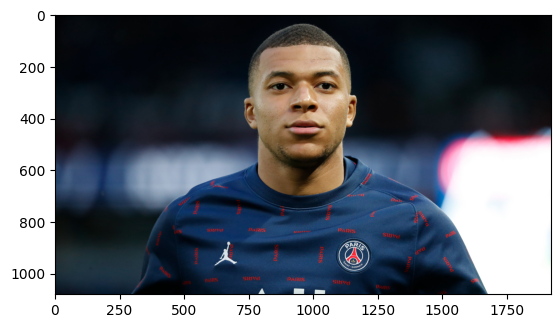

In [3]:
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2RGB = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3RGB = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
plt.imshow(imgRGB)

## Converting to GreyScale

In [4]:
#Laplacian needs images to be in grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray_img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray_img.shape

(1080, 1920)

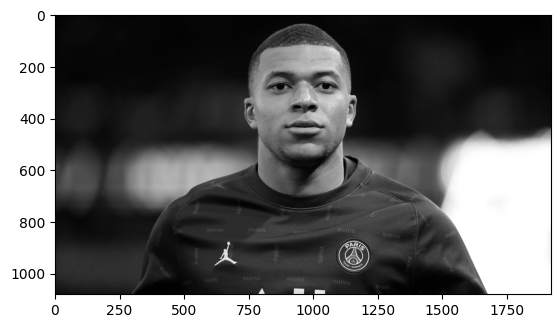

In [5]:
plt.imshow(gray_img, cmap='gray')


## Reducing Noise with Median Filter

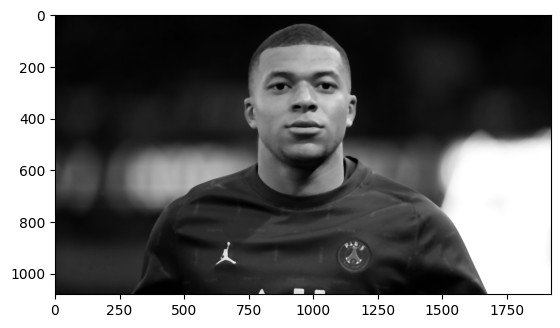

In [6]:
medianFilter_img = cv2.medianBlur(gray_img, 9)
medianFilter_img2 = cv2.medianBlur(gray_img2, 9)
medianFilter_img3 = cv2.medianBlur(gray_img3, 9)
plt.imshow(medianFilter_img, cmap='gray')

## Edge Detection using Laplacian Filter

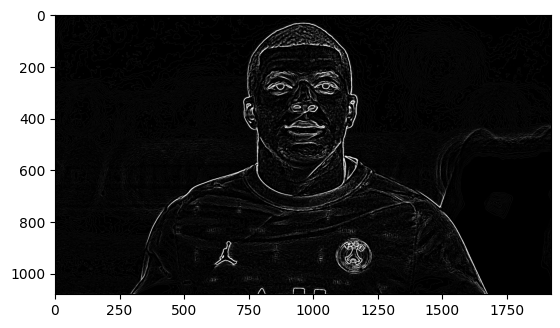

In [7]:
img_edges = cv2.Laplacian(medianFilter_img, ddepth=cv2.CV_8U, ksize=5) # depth = 8 bit unsigned integer (0-255)
img_edges2 = cv2.Laplacian(medianFilter_img2, ddepth=cv2.CV_8U, ksize=5)
img_edges3 = cv2.Laplacian(medianFilter_img3, ddepth=cv2.CV_8U, ksize=5)
plt.imshow(img_edges, cmap='gray')

## Applying Binary threshold

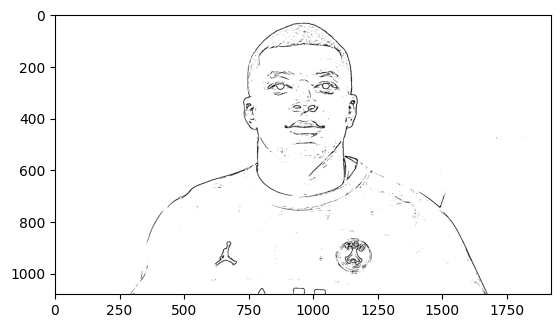

In [8]:
binary_threshold_img = cv2.threshold(img_edges, 127, 255, cv2.THRESH_BINARY_INV)[1] # pixels below 127 are white, otherwise black, [1] to select the image only
binary_threshold_img2 = cv2.threshold(img_edges2, 127, 255, cv2.THRESH_BINARY_INV)[1]
binary_threshold_img3 = cv2.threshold(img_edges3, 127, 255, cv2.THRESH_BINARY_INV)[1]
plt.imshow(binary_threshold_img, cmap='gray')

## Color Painting Using Bilateral Filter

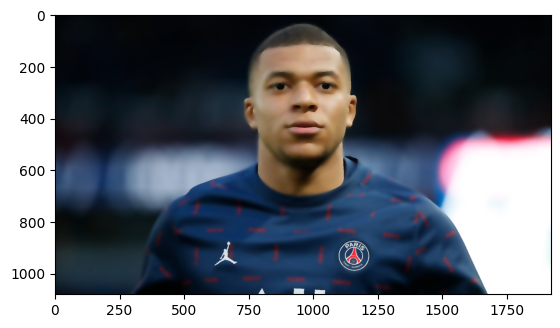

In [9]:
bilateralFilter_img = cv2.bilateralFilter(imgRGB, d=9, sigmaColor=80, sigmaSpace=80) # d = diameter of each pixel neighborhood, sigmaColor = is how close is the color to be blurred together, sigmaSpace = is how close the pixels need to be to each other to be blurred together
bilateralFilter_img2 = cv2.bilateralFilter(img2RGB, d=9, sigmaColor=80, sigmaSpace=80)
bilateralFilter_img3 = cv2.bilateralFilter(img3RGB, d=9, sigmaColor=80, sigmaSpace=80)
plt.imshow(bilateralFilter_img)
for i in range(7):
    bilateralFilter_img = cv2.bilateralFilter(bilateralFilter_img, d=9, sigmaColor=80, sigmaSpace=80)
    bilateralFilter_img2 = cv2.bilateralFilter(bilateralFilter_img2, d=9, sigmaColor=80, sigmaSpace=80)
    bilateralFilter_img3 = cv2.bilateralFilter(bilateralFilter_img3, d=9, sigmaColor=80, sigmaSpace=80)
plt.imshow(bilateralFilter_img)

## Overlaying painting on the Sketch

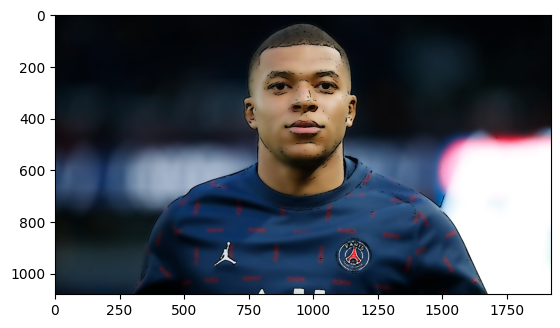

In [10]:
# black_background = np.zeros_like(bilateralFilter_img)
# cartoon_img = cv2.copyTo(src=bilateralFilter_img, mask=binary_threshold_img, dst=black_background)
cartoon_img = cv2.bitwise_and(bilateralFilter_img, bilateralFilter_img, mask=binary_threshold_img) # takes 2 sources, ands zeroes the pixels where the mask is black, and keeps the pixels where the mask is white
plt.imshow(cartoon_img)

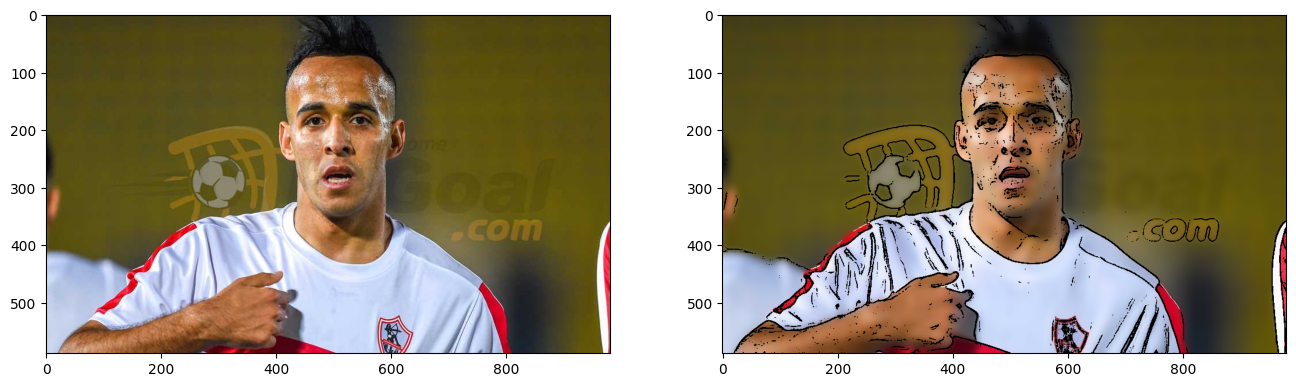

In [11]:
cartoon_img2 = cv2.bitwise_and(bilateralFilter_img2, bilateralFilter_img2, mask=binary_threshold_img2) # takes 2 sources
plt.figure(figsize=(16,8))
plt.subplot(1, 2, 1)
plt.imshow(img2RGB)
plt.subplot(1, 2, 2)
plt.imshow(cartoon_img2)

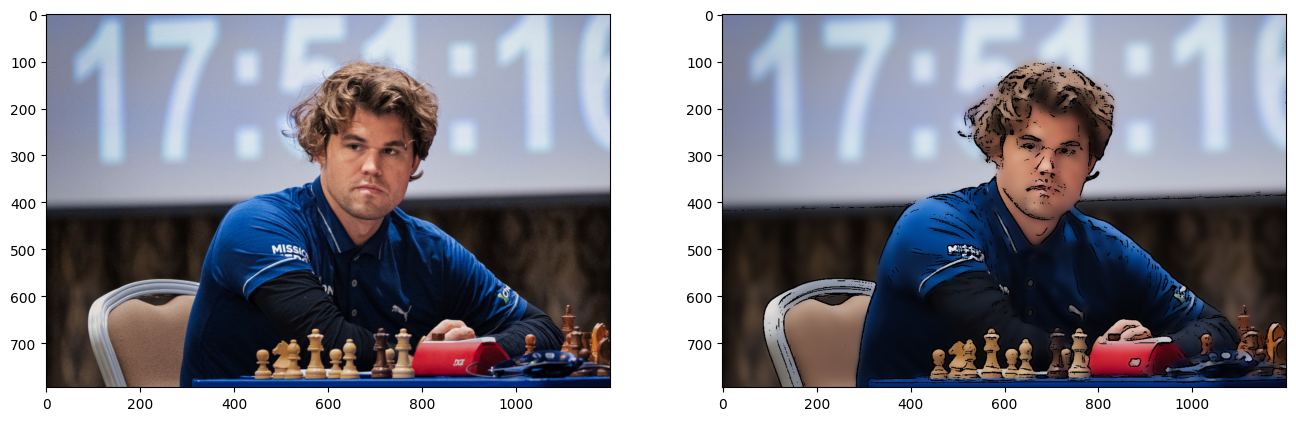

In [12]:
cartoon_img3 = cv2.bitwise_and(bilateralFilter_img3, bilateralFilter_img3, mask=binary_threshold_img3) # takes 2 sources
plt.figure(figsize=(16,8))
plt.subplot(1, 2, 1)
plt.imshow(img3RGB)
plt.subplot(1, 2, 2)
plt.imshow(cartoon_img3)